In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

In [2]:
def print_report(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
    print(f"AUC Score: {roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")}")
    print(f"Precision Score: {precision_score(y_test, y_pred,average="macro")}")
    print(f"Recall Score: {recall_score(y_test, y_pred,average="macro")}")
    print(f"F1 score: {f1_score(y_test, y_pred,average="macro")}")
    print(f"Matthews Correlation Coefficient: {matthews_corrcoef(y_test, y_pred)}")

In [3]:
training_file = "../data/training/training_data.csv"

col_to_drop = ["time_to_10soc",
    "time_to_25soc", 
    "time_to_40soc", 
    "time_to_50soc",
    "curr_min"]

df = pd.read_csv(training_file)
df.drop(col_to_drop, axis=1, inplace=True)

In [4]:
X = df.drop('degradation', axis=1)
y = df['degradation']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

In [6]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
help(GaussianNB)

Help on class GaussianNB in module sklearn.naive_bayes:

class GaussianNB(_BaseNB)
 |  GaussianNB(*, priors=None, var_smoothing=1e-09)
 |
 |  Gaussian Naive Bayes (GaussianNB).
 |
 |  Can perform online updates to model parameters via :meth:`partial_fit`.
 |  For details on algorithm used to update feature means and variance online,
 |  see `Stanford CS tech report STAN-CS-79-773 by Chan, Golub, and LeVeque
 |  <http://i.stanford.edu/pub/cstr/reports/cs/tr/79/773/CS-TR-79-773.pdf>`_.
 |
 |  Read more in the :ref:`User Guide <gaussian_naive_bayes>`.
 |
 |  Parameters
 |  ----------
 |  priors : array-like of shape (n_classes,), default=None
 |      Prior probabilities of the classes. If specified, the priors are not
 |      adjusted according to the data.
 |
 |  var_smoothing : float, default=1e-9
 |      Portion of the largest variance of all features that is added to
 |      variances for calculation stability.
 |
 |      .. versionadded:: 0.20
 |
 |  Attributes
 |  ----------
 |  cla

In [8]:
model = GaussianNB()
model

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [9]:
model.fit(X_train_scaled,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[128.,100.,173.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.32,0.25,0.43]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,3]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['volt_start','volt_end','volt_std',...,'curr_avg','curr_std', 'time_to_0soc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 11)","[[ 0.04,-0.15,-0.83,..., 0.18, 0.23, 1.17], [ 0.47,-0.14, 0.03,..., 0.07,-0.6 , 0.14], [-0.3 , 0.2 , 0.6 ,...,-0.17, 0.17,-0.95]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 11)","[[0.97,1.32,0.84,...,1.27,1.95,0.16], [0.81,1.02,0.77,...,1.15,0.24,0.15], [0.91,0.68,0.39,...,0.66,0.46,0.19]]"


In [10]:
y_test_predict = model.predict(X_test_scaled)
y_train_predict = model.predict(X_train_scaled)

In [11]:
print(f"Training Accuracy Score: {accuracy_score(y_train, y_train_predict)}")
print(f"Testing Accuracy Score: {accuracy_score(y_test, y_test_predict)}")

Training Accuracy Score: 0.8628428927680798
Testing Accuracy Score: 0.7722772277227723


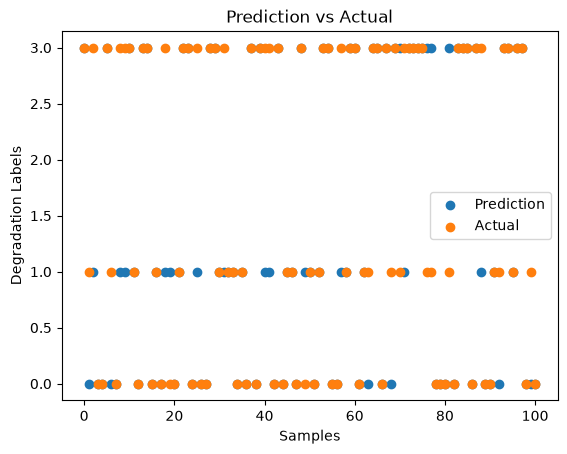

In [12]:
plt.scatter(range(len(y_test_predict)), y_test_predict, label="Prediction")
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.xlabel("Samples")
plt.ylabel("Degradation Labels")
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

              precision    recall  f1-score   support

           0       0.83      0.94      0.88        32
           1       0.54      0.60      0.57        25
           3       0.89      0.75      0.81        44

    accuracy                           0.77       101
   macro avg       0.75      0.76      0.75       101
weighted avg       0.79      0.77      0.77       101

Accuracy Score: 0.7722772277227723
AUC Score: 0.9373880105401845
Precision Score: 0.7536465036465035
Recall Score: 0.7625000000000001
F1 score: 0.7544018306134473
Matthews Correlation Coefficient: 0.6580232819533498


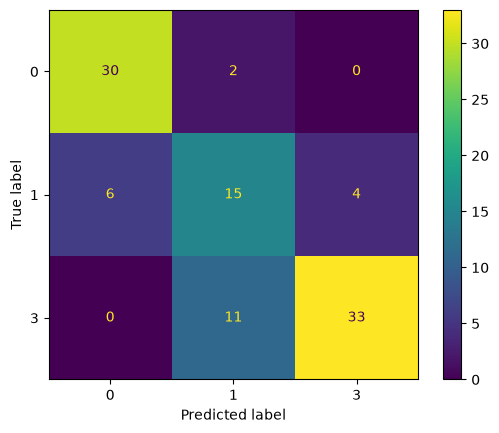

In [13]:
print_report(model, X_test_scaled, y_test)

# GridSearchCV

In [14]:
param_grid = {
    'var_smoothing': np.logspace(-11, -1, num=100)
}

In [15]:
model = GaussianNB()
grid_model = GridSearchCV(model, param_grid=param_grid, cv=5)

In [16]:
grid_model.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-01])}
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with 

In [17]:
grid_model.best_params_

{'var_smoothing': np.float64(1e-11)}

In [18]:
y_train_predict_grid = grid_model.predict(X_train_scaled)
y_pred = grid_model.predict(X_test_scaled)
print(f"Training accuracy: {accuracy_score(y_train, y_train_predict_grid)}")
print(f"Testing accuracy: {accuracy_score(y_test, y_pred)}")

Training accuracy: 0.8628428927680798
Testing accuracy: 0.7722772277227723


              precision    recall  f1-score   support

           0       0.83      0.94      0.88        32
           1       0.54      0.60      0.57        25
           3       0.89      0.75      0.81        44

    accuracy                           0.77       101
   macro avg       0.75      0.76      0.75       101
weighted avg       0.79      0.77      0.77       101

Accuracy Score: 0.7722772277227723
AUC Score: 0.9373880105401845
Precision Score: 0.7536465036465035
Recall Score: 0.7625000000000001
F1 score: 0.7544018306134473
Matthews Correlation Coefficient: 0.6580232819533498


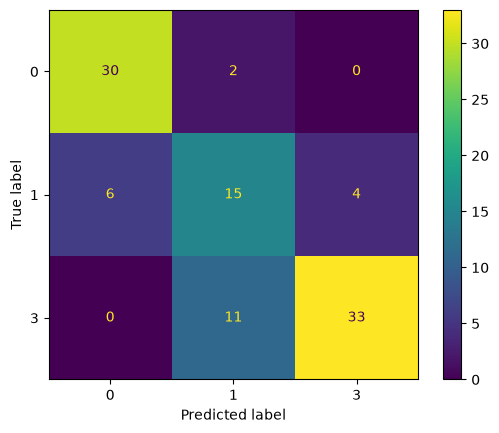

In [19]:
print_report(grid_model, X_test_scaled, y_test)

In [20]:
import joblib

In [21]:
joblib.dump(grid_model, "gaussian_naive_bayes.pkl")
joblib.dump(scaler, "gaussian_naive_bayes_scaler.pkl")

['gaussian_naive_bayes_scaler.pkl']

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        40
           1       0.69      0.77      0.73        31
           3       0.96      0.85      0.90        55

    accuracy                           0.86       126
   macro avg       0.84      0.85      0.84       126
weighted avg       0.87      0.86      0.86       126

Accuracy Score: 0.8571428571428571
AUC Score: 0.9631249873506856
Precision Score: 0.8419501133786849
Recall Score: 0.8512463343108504
F1 score: 0.844519301836375
Matthews Correlation Coefficient: 0.7844014833224758


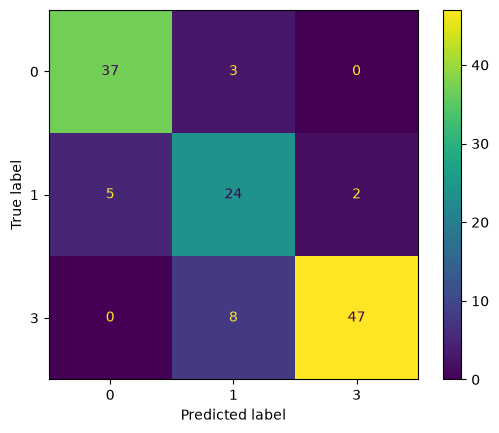

In [22]:
trained_model = joblib.load("gaussian_naive_bayes.pkl")
trained_scaler = joblib.load("gaussian_naive_bayes_scaler.pkl")

test_df = pd.read_csv("../data/testing/test_data.csv")
test_df.drop(col_to_drop, axis=1, inplace=True)
X = test_df.drop("degradation", axis=1)
y = test_df['degradation']

X_scaled = trained_scaler.transform(X)

y_hat = trained_model.predict(X_scaled)
print_report(trained_model, X_scaled, y)